# Airbnb Price Analysis en Nueva York

## 1. Pregunta de negocio
**¿Que factores influyen en los precios de Airbnb en Nueva York?**

**Objetivos:**
- Entender la estructura del dataset
- Evaluar la calidad de los datos
- Limpiar la data
- Explorar la relacion entre las variables
- Identificar el factor que mas influye en el precio mediante modelado predictivo 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot') #estetico
pd.set_option('display.max_columns', None) #configuracion visual, vemos todos las obs

df = pd.read_csv('../data/raw/AB_NYC_2019.csv')

## 2. Comprension de datos
Exploracion inicial para conocer el dataset, los tipos de datos y las estadisticas basicas.

Primero miramos las primeras filas para entender como es la estructura del dataset.

In [2]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


Con df.info() vemos el tipo de cada variable y si tiene nulos, y la cantidad de observaciones y features que tiene el dataset.

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

Ahora vemos informacion estadistica sobre cada variable.

In [4]:
df.describe()


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


## 3. Limpieza de datos
En esta seccion revisamos valores nulos, duplicados y anomalias que puedan afectar el analisis.

- `last_review` y `reviews_per_month` tienen la misma cantidad de valores nulos (10052). Lo mas probable es que no tengan ninguna reseña. Se imputaran los faltantes en `reviews_per_month` con 0 (`last_review` no nos interesa)
- Existen observaciones con valor 0 en el precio, lo cual es poco probable que sea un precio real, y dado que representan un porcentaje muy bajo, las eliminamos.

In [5]:
df.isnull().sum().sort_values(ascending=False)


last_review                       10052
reviews_per_month                 10052
host_name                            21
name                                 16
neighbourhood_group                   0
neighbourhood                         0
id                                    0
host_id                               0
longitude                             0
latitude                              0
room_type                             0
price                                 0
number_of_reviews                     0
minimum_nights                        0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [6]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0) # completamos valores faltantes

In [7]:
df['price'].sort_values().head(20) 


26841     0
25753     0
26866     0
25433     0
26259     0
23161     0
25796     0
25794     0
25634     0
25795     0
25778     0
35601    10
21700    10
33505    10
31407    10
34446    10
24100    10
27972    10
23256    10
22261    10
Name: price, dtype: int64

In [8]:
df = df[df['price'] > 0] # nos quedamos solo con los valores mayores a 0

In [9]:
print(f'Cantidad de duplicados: {df.duplicated().sum()}')


Cantidad de duplicados: 0


In [10]:
barrios_cant_tags = df['neighbourhood'].nunique()
cuartos_cant_tags = df['room_type'].nunique()

print(f'Tenemos {barrios_cant_tags} de barrios distintos y {cuartos_cant_tags} tipos de alojamiento distintas')
# los barrios estan agrupados en neighbourhood_group

Tenemos 221 de barrios distintos y 3 tipos de alojamiento distintas


## 4. Analisis exploratorio de datos (EDA)
### 4.1 Distribucion del precio

Text(0.5, 1.0, 'Distribucion de los precios')

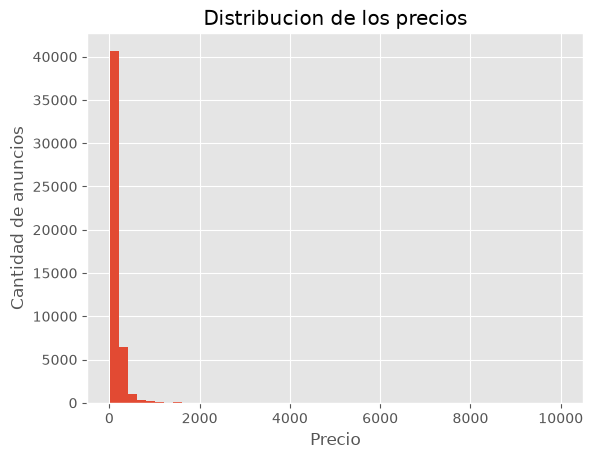

In [11]:
plt.hist(df['price'], bins=50)
plt.xlabel('Precio')
plt.ylabel('Cantidad de anuncios')
plt.title('Distribucion de los precios')

Hay 2972 outliers en Price, un 6.08%


Text(0.5, 0, 'Anuncios')

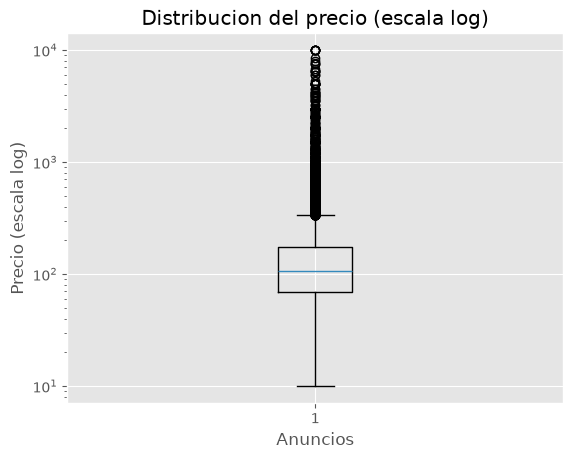

In [12]:
boxplot_price = plt.boxplot(df['price'])
cant_outliers = len(boxplot_price['fliers'][0].get_ydata())
porcentaje_outlier =  cant_outliers / len(df) * 100
plt.yscale('log')
print(f'Hay {cant_outliers} outliers en Price, un {round(porcentaje_outlier, 2)}%')
plt.title('Distribucion del precio (escala log)')
plt.ylabel('Precio (escala log)')
plt.xlabel('Anuncios')

In [13]:
print(f"Mediana del precio: ${df['price'].median()}")
print(f"Media del precio: ${df['price'].mean():.2f}")



Mediana del precio: $106.0
Media del precio: $152.76


*Observacion:* La mediana es de 106 mientras que la media es de 152. La muestra esta sesgada hacia la derecha, haciendo que los outliers eleven la media.

### 4.2 Precio segun tipo de alojamiento

Text(0, 0.5, 'Precio (escala log)')

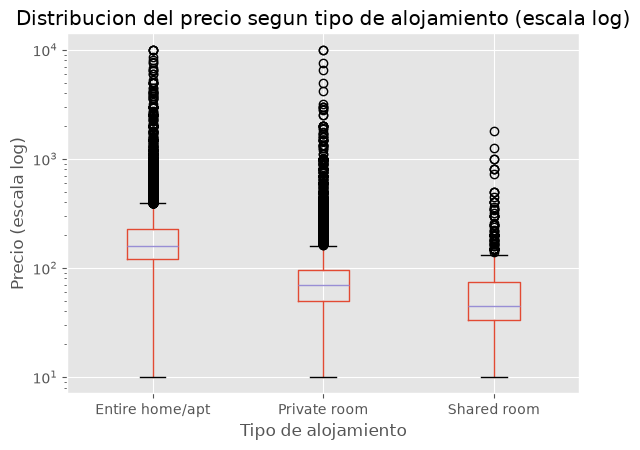

In [14]:
df.boxplot(column='price', by='room_type')
plt.yscale('log') 
plt.title('Distribucion del precio segun tipo de alojamiento (escala log)')
plt.suptitle('')
plt.xlabel('Tipo de alojamiento')
plt.ylabel('Precio (escala log)')


In [15]:
df.groupby('room_type')['price'].agg( ['count', 'mean', 'median', 'min', 'max']
).sort_values('mean', ascending=False) # agrupamos por tipo de alojamiento, y calculamos sobre el precio

,count,mean,median,min,max
room_type,,,,,
Entire home/apt,25407,211.810918,160.0,10,10000
Private room,22319,89.809131,70.0,10,10000
Shared room,1158,70.248705,45.0,10,1800


*Observacion:* Los alojamientos completos en Manhattan tiene una mediana mayor del precio, mientras que los alojamientos compartidos en Staten Island tienen la mediana mas baja
### 4.3 Precio segun zona

Text(0, 0.5, 'Precio (escala log)')

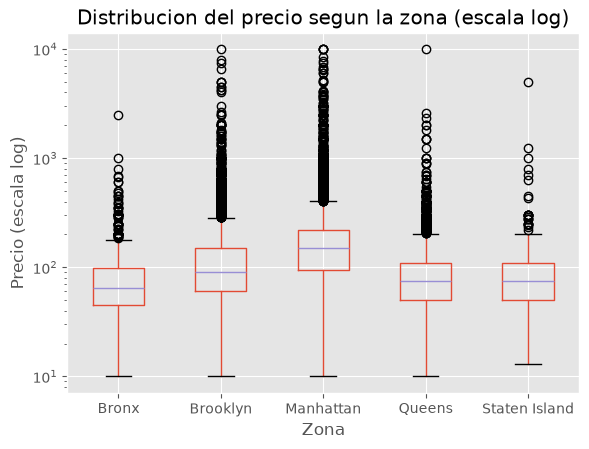

In [16]:
df.boxplot(column='price', by='neighbourhood_group')
plt.yscale('log')
plt.title('Distribucion del precio segun la zona (escala log)')
plt.suptitle('')
plt.xlabel('Zona')
plt.ylabel('Precio (escala log)')

In [17]:
df.groupby('neighbourhood_group')['price'].agg( ['count', 'mean', 'median', 'min', 'max']
).sort_values('mean', ascending=False) # vemos por zonas 

,count,mean,median,min,max
neighbourhood_group,,,,,
Manhattan,21660,196.884903,150.0,10,10000
Brooklyn,20095,124.438915,90.0,10,10000
Staten Island,373,114.812332,75.0,13,5000
Queens,5666,99.517649,75.0,10,10000
Bronx,1090,87.577064,65.0,10,2500


Usamos Kruskal-Wallis (no parametrico) porque el precio no sigue una distribucion normal.

In [33]:
from scipy.stats import kruskal

# segun tipo de alojamiento
grupos_room = [grupo['price'].values for _, grupo in df.groupby('room_type')]
stat_room, p_room = kruskal(*grupos_room)

print(f'Tipo de alojamiento\nEstadistico: {stat_room:.2f}')
print(f'p-valor: {p_room:.4e}')

# segun zona
grupos_zona = [grupo['price'].values for _, grupo in df.groupby('neighbourhood_group')]
stat_zona, p_zona = kruskal(*grupos_zona)

print(f'\nZona\nEstadistico: {stat_zona:.2f}')
print(f'p-valor: {p_zona:.4e}')

alpha = 0.05

if p_room < alpha:
    print('\nExiste evidencia suficiente para afirmar que el precio difiere segun el tipo de alojamiento.')
else:
    print('\nNo se encontraron diferencias significativas entre los tipos de alojamiento.')

if p_zona < alpha:
    print('Existe evidencia suficiente para afirmar que el precio difiere segun la zona.')
else:
    print('No se encontraron diferencias significativas entre la zona.')

Tipo de alojamiento
Estadistico: 22414.84
p-valor: 0.0000e+00

Zona
Estadistico: 7023.12
p-valor: 0.0000e+00

Existe evidencia suficiente para afirmar que el precio difiere segun el tipo de alojamiento.
Existe evidencia suficiente para afirmar que el precio difiere segun la zona.


### 4.4 Precio segun minimo de noches
`minimum_nights` tiene un maximo muy elevado, por lo que vamos a comprobar si se trata de outliers

Text(0, 0.5, 'Frecuencia')

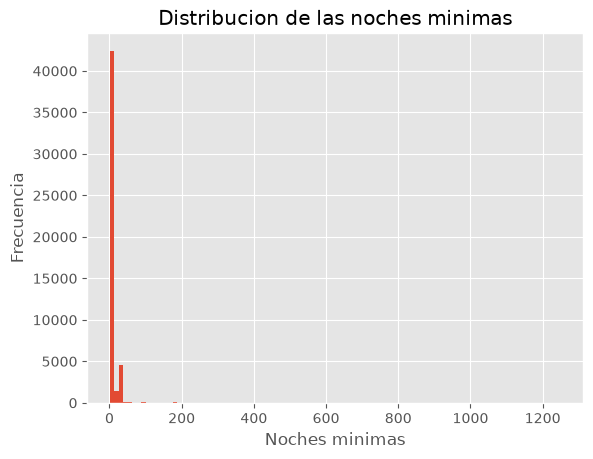

In [19]:
plt.hist(df['minimum_nights'], bins=100)

plt.title('Distribucion de las noches minimas')
plt.xlabel('Noches minimas')
plt.ylabel('Frecuencia')


Hay 6605 outliers en minimum_nights, un 13.51%


Text(0.5, 0, 'Anuncios')

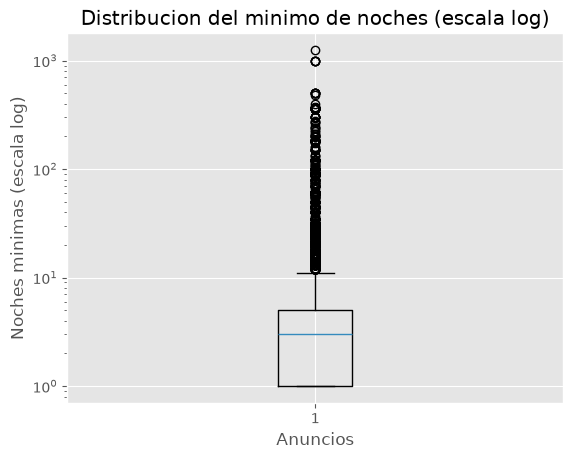

In [20]:
boxplot_minimum_nights = plt.boxplot(df['minimum_nights'])
cant_outliers = len(boxplot_minimum_nights['fliers'][0].get_ydata())
porcentaje_outlier =  cant_outliers / len(df) * 100
plt.yscale('log')
print(f'Hay {cant_outliers} outliers en minimum_nights, un {round(porcentaje_outlier, 2)}%')
plt.title('Distribucion del minimo de noches (escala log)')
plt.suptitle('')
plt.ylabel('Noches minimas (escala log)')
plt.xlabel('Anuncios')


*Observacion:* La mayoria de los alojamientos requieren pocas noches minimas para reservar. Aunque se pueden observar valores muy altos superando las 1200 noches. Esto puede ser porque son alquileres de larga duracion o por alguna anomalia. Como no podemos saber a que se deben, para evitar perder informacion los vamos a dejar.

### 4.5 Correlacion entre variables numericas

<Axes: >

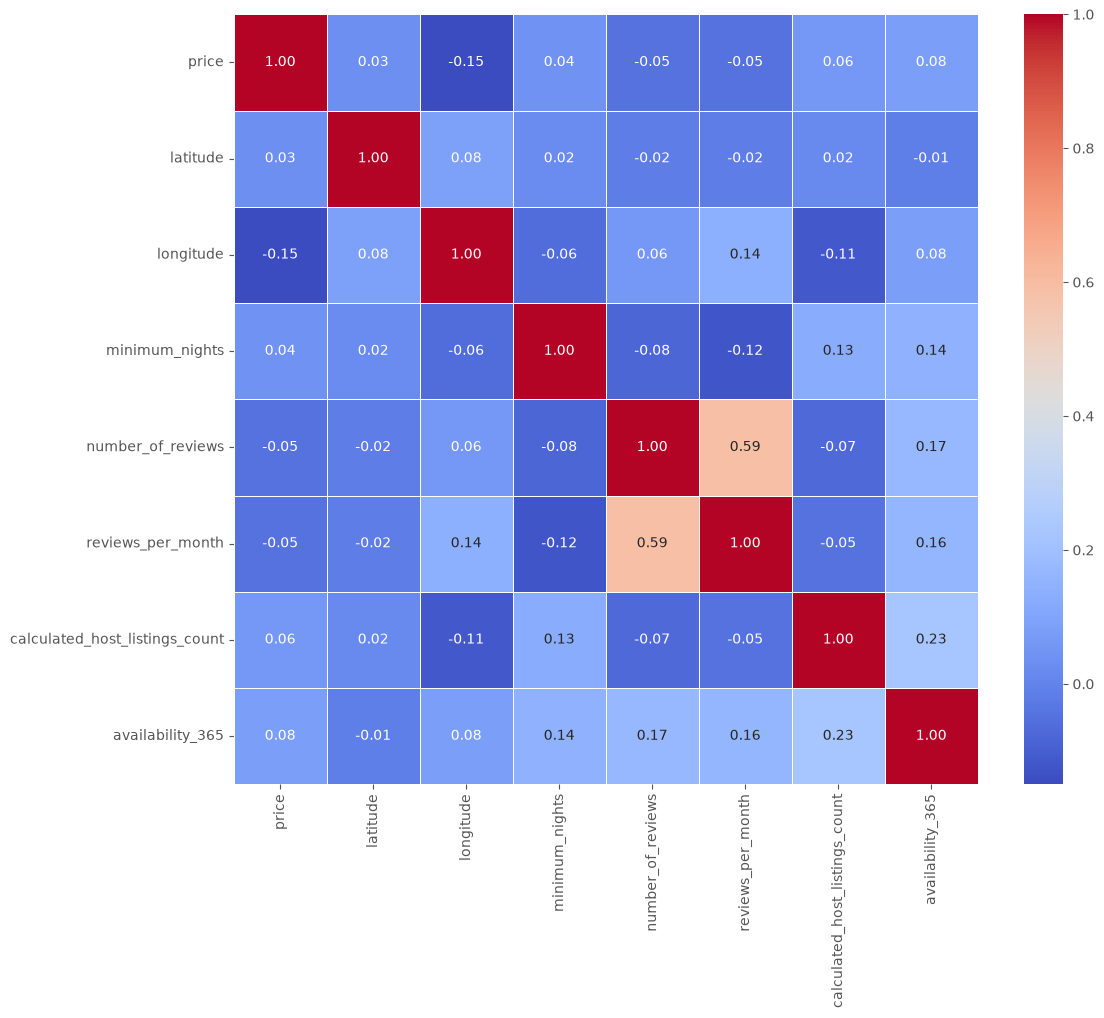

In [21]:
variables_numericas = [
    'price',
    'latitude', 
    'longitude', 
    'minimum_nights', 
    'number_of_reviews', 
    'reviews_per_month', 
    'calculated_host_listings_count', 
    'availability_365'
]

corr_matriz= df[variables_numericas].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matriz, annot= True, cmap='coolwarm', fmt='.2f', linewidths=0.5)




*Observacion:* No hay correlacion lineal fuerte con la variable target. La unica que mas o menos destaca es `longitude` con una correlacion negativa de -0.15.

In [22]:
(
    df.groupby(['neighbourhood_group', 'room_type'])['price']
      .median()
      .sort_values(ascending=False)
)

neighbourhood_group  room_type      
Manhattan            Entire home/apt    191.0
Brooklyn             Entire home/apt    145.0
Queens               Entire home/apt    120.0
Staten Island        Entire home/apt    100.0
Bronx                Entire home/apt    100.0
Manhattan            Private room        90.0
                     Shared room         69.0
Brooklyn             Private room        65.0
Queens               Private room        60.0
Bronx                Private room        54.0
Staten Island        Private room        50.0
Bronx                Shared room         40.0
Queens               Shared room         37.0
Brooklyn             Shared room         36.0
Staten Island        Shared room         30.0
Name: price, dtype: float64

## 5. Modelo predictivo
Preparacion de los datos y creacion de un modelo para predecir el precio y encontrar los factores mas importantes. Como el precio esta muy sesgado, aplicamos una transformacion logaritmica.

In [23]:
df_modelo = pd.get_dummies(df, columns=['room_type', 'neighbourhood_group'], drop_first=True)
df_modelo.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood', 'latitude',
       'longitude', 'price', 'minimum_nights', 'number_of_reviews',
       'last_review', 'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'room_type_Private room', 'room_type_Shared room',
       'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan',
       'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island'],
      dtype='str')

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

columnas_x = [
    'latitude', 
    'longitude', 
    'minimum_nights', 
    'number_of_reviews', 
    'reviews_per_month', 
    'calculated_host_listings_count', 
    'availability_365', 
    'room_type_Private room', 
    'room_type_Shared room',       
    'neighbourhood_group_Brooklyn', 
    'neighbourhood_group_Manhattan',       
    'neighbourhood_group_Queens', 
    'neighbourhood_group_Staten Island'
]

X = df_modelo[columnas_x]
y = np.log1p(df_modelo["price"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### 5.1. Benchmark (Dummy + Regresion Lineal)

In [25]:

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression

y_test_price = np.expm1(y_test) #escala original

# benchmark 1: Dummy Regressor (predice siempre la media)
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)

y_pred_dummy = np.expm1(dummy.predict(X_test))

mae_dummy = mean_absolute_error(y_test_price, y_pred_dummy)
r2_dummy = r2_score(y_test_price, y_pred_dummy)

print('Dummy Regressor')
print(f'MAE: ${mae_dummy:.2f}')
print(f'R^2 : {r2_dummy:.4f}')

# benchmark 2: Regresion Lineal
linear = LinearRegression()
linear.fit(X_train, y_train)

y_pred_linear = np.expm1(linear.predict(X_test))

mae_linear = mean_absolute_error(y_test_price, y_pred_linear)
r2_linear = r2_score(y_test_price, y_pred_linear)

print('\nRegresion Lineal')
print(f'MAE: ${mae_linear:.2f}')
print(f'R^2 : {r2_linear:.4f}')

Dummy Regressor
MAE: $82.87
R^2 : -0.0357

Regresion Lineal
MAE: $61.98
R^2 : 0.1077


### 5.2 Decision Tree
Usamos Arbol de decision por su interpretabilidad y capacidad para capturar relaciones no lineales.
#### Grid Search Cross-Validation

In [26]:
from sklearn.model_selection import GridSearchCV

parametros = {
    'max_depth':[3,5,8,10,15],
    'min_samples_leaf':[1,5,10,20],
    'min_samples_split':[2,5,10,20]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    parametros,
    cv=5,
    scoring='r2'
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

{'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 2}


#### Metricas

In [27]:
arbol = grid_search.best_estimator_

pred_log = arbol.predict(X_test) # predecimos en escala log

pred_price = np.expm1(pred_log) # escala original 
y_test_price = np.expm1(y_test)

mae = mean_absolute_error(y_test_price, pred_price) 
r2 = r2_score(y_test_price, pred_price)

print('Resultados del Decision Tree')
print(f'Error Absoluto Medio (MAE): ${mae:.2f}')
print(f'R-cuadrado (R²): {r2:.4f}')

Resultados del Decision Tree
Error Absoluto Medio (MAE): $58.01
R-cuadrado (R²): 0.1662


*Observacion:*  El modelo explica el 16.62% de la variacion de los precios. Esto ya supera al benchmark dummy de R^2=-0.04 y a la regresion lineal de R^2=0.11, por lo que capturar la relacion no lineal aporta valor.

### 5.3 Random Forest

Usamos el modelo de Random Forest para mejorar el rendimiento reduciendo la varianza de un unico arbol.

#### Random Search Cross-validation

In [28]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

parametros = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5],
}

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=parametros,
    n_iter=5,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)
print(random_search.best_score_)

{'n_estimators': 100, 'min_samples_leaf': 5, 'max_depth': None}
0.6004441058107425


#### Metricas e importancia de las variables

Resultados del Random Forest
MAE (precio): $55.70
R^2 (escala log): 0.5959
R^2 (precio original): 0.2007
Importancia de las variables:
                             Variable  Importancia
7              room_type_Private room     0.396631
1                           longitude     0.149950
0                            latitude     0.126407
8               room_type_Shared room     0.081208
6                    availability_365     0.070129
2                      minimum_nights     0.042905
4                   reviews_per_month     0.042426
3                   number_of_reviews     0.034626
10      neighbourhood_group_Manhattan     0.029921
5      calculated_host_listings_count     0.024867
11         neighbourhood_group_Queens     0.000507
9        neighbourhood_group_Brooklyn     0.000372
12  neighbourhood_group_Staten Island     0.000052


Text(0, 0.5, '')

<Figure size 1000x600 with 0 Axes>

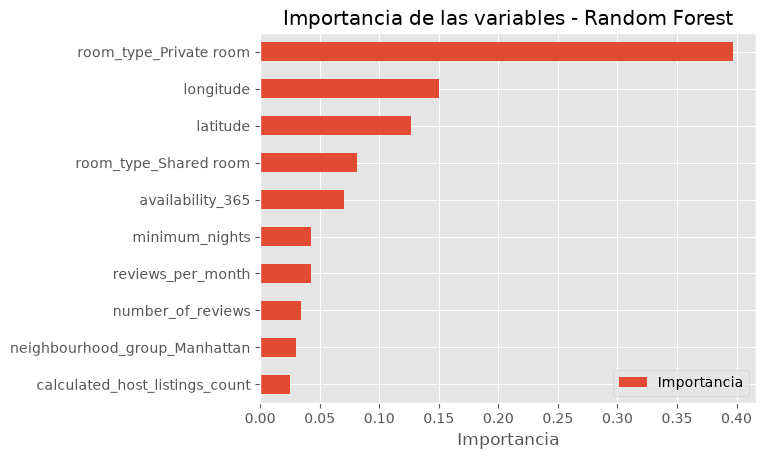

In [29]:
rf = random_search.best_estimator_ 
pred_log = rf.predict(X_test) # predicciones en escala log



r2_log = r2_score(y_test, pred_log) # R^2 sobre la escala log

pred_price = np.expm1(pred_log) # escala original
y_test_price = np.expm1(y_test)

mae = mean_absolute_error(y_test_price, pred_price)
r2_precio = r2_score(y_test_price, pred_price)

print('Resultados del Random Forest')
print(f'MAE (precio): ${mae:.2f}')
print(f'R^2 (escala log): {r2_log:.4f}')
print(f'R^2 (precio original): {r2_precio:.4f}')

importancias = ( 
    pd.DataFrame({
        'Variable': X.columns,
        'Importancia': rf.feature_importances_
    })
    .sort_values(by="Importancia", ascending=False)
)

print('Importancia de las variables:')
print(importancias)
plt.figure(figsize=(10,6)) 
importancias.head(10).sort_values(by='Importancia', ascending=True).plot(
    kind='barh', 
    x='Variable', 
    y='Importancia', 
)
plt.title('Importancia de las variables - Random Forest') 
plt.xlabel('Importancia')
plt.ylabel('')

*Observacion:*  Comparado con el benchmark y con el arbol de decision individual, el modelo de Random Forest explica el 20.07% de la variacion de los precios. Esto confirma que el modelo esta capturando señal real (probablemente interacciones entre zona y tipo de alojamiento), aunque el techo general siga siendo bajo por la falta de variables como tamaño, amenities o fotos.
El analisis exploratorio muestra que el tipo de alojamiento y la zonas son los factores principales asociados con los precios de Airbnb. El modelo de random forest aporta a esto asignandoles mayor importancia a estas variables.

#### Cross-validation

In [30]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f'R^2 por fold: {np.round(cv_scores, 4)}')
print(f'R^2 promedio (5-fold CV): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

R^2 por fold: [0.5035 0.5733 0.5744 0.6041 0.5441]
R^2 promedio (5-fold CV): 0.5599 (+/- 0.0340)


*Observacion:* El R^2 en cross-validation en escala logaritmica es de 0.5599 (+/- 0.0340), lo que confirma que el modelo generaliza de forma estable y que el split original de 0.60 es ligeramente optimista. 

## 6. Prediccion vs Valor real
Vamos a comparar visualmente los valores predichos con los valores reales utilizando el percentil 99 para una mejor visualizacion de los datos.

Text(0, 0.5, 'Precio predicho ($)')

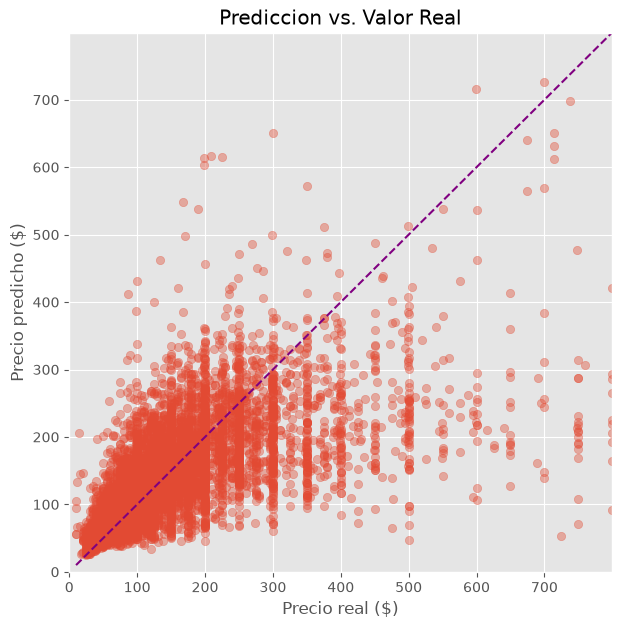

In [31]:
y_pred = np.expm1(rf.predict(X_test))
y_real = np.expm1(y_test)

plt.figure(figsize=(7,7))

plt.scatter(y_real, y_pred, alpha=0.4)

limite = np.percentile(y_real, 99)

plt.xlim(0, limite)
plt.ylim(0, limite)

min_val = min(y_real.min(), y_pred.min()) 
max_val = max(y_real.max(), y_pred.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         color='purple',
         linestyle='--')

plt.title('Prediccion vs. Valor Real')
plt.xlabel('Precio real ($)')
plt.ylabel('Precio predicho ($)')


*Observacion:* El grafico muestra una relacion positiva entre lo predicho y lo real. Sin embargo, el modelo tiende a subestimar los alojamientos con mayor precio. Este comportamiento es consistente con la distribucion sesgada de la variable `price` y la presencia de outliers. 

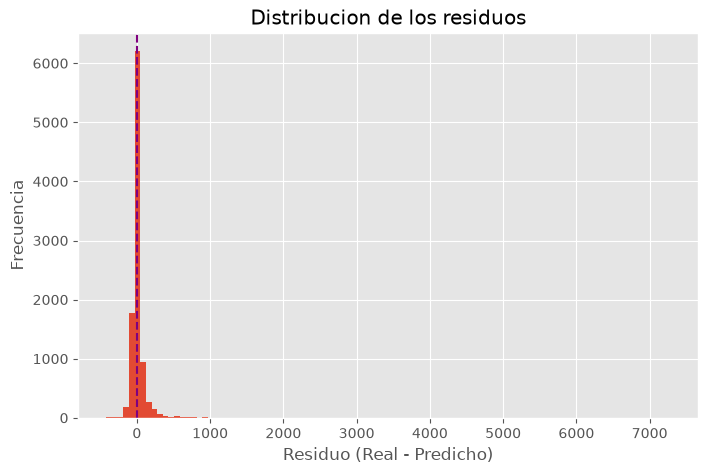

In [32]:
residuos = y_real - y_pred

plt.figure(figsize=(8,5))

plt.hist(residuos, bins=100)

plt.axvline(0, color='purple', linestyle='--')

plt.xlabel('Residuo (Real - Predicho)')
plt.ylabel('Frecuencia')
plt.title('Distribucion de los residuos')

plt.show()

## 7. Descubrimientos
- La distribucion del precio esta sesgada hacia la derecha. La mayoria de los precios de los anuncios estan concentrados en los precios mas bajos, mientras que un grupo menor tienen un mayor valor.

- El tipo de alojamiento es una de las variables mas relacionadas con el precio. Las casas/apartamentos completos presentan mayores precios que cuartos compartidos.

- Los tests de Kruskal-Wallis confirman que las diferencias de precio segun tipo de alojamiento y zona son estadisticamente significativas (p casi 0 en ambos casos), aunque con 48895 filas hasta diferencias chicas resultan "significativas".

- Manhattan tienen los mayores precios. Los anuncios en manhattan tienen una mayor mediana que las demas zonas.

- las variables numericas tienen una relacion debil con el precio. Podemos ver por la matriz de correlacion que las variables tienen coeficientes muy cercanos a cero.

- Random Forest confirma la importancia de la zona y del tipo de alojamiento, utilizandolas en mayor medida.

## 8. Limitaciones
- El dataset no incluye el tamaño de las propiedades ni si incluye amenities.
- Las comparaciones entre grupos (tipo de alojamiento, zona) se complementaron con tests de Kruskal-Wallis
- Todos los anuncios que tenian valor 0, fueron eliminados.
- Hay mas factores que influyen fuertemente en el precio que no son incluidos al dataset.


## 9. A futuro
- Incorporar nuevas variables derivadas de las existentes, como la longitud del titulo del alojamiento, la presencia de palabras clave (por ejemplo, *luxury*, *cozy* o *private*), la antiguedad de la ultima reseña y la distancia a un punto de referencia de la ciudad (por ejemplo, Times Square).
- Explorar el uso de `neighbourhood` (221 categorias) en lugar de `neighbourhood_group` (5 categorias), aplicando tecnicas para variables de alta cardinalidad como *Target Encoding* o *Frequency Encoding*, con el objetivo de capturar diferencias de precio mas especificas entre barrios.
- Optimizar mas los hiperparametros (mayor rango de busqueda, mas iteraciones).
- Comparar el desempeño del Random Forest con otros modelos basados en arboles, como Gradient Boosting o XGBoost.


En conjunto, este proyecto permitio desarrollar un flujo completo de analisis de datos, desde la limpieza y exploracion hasta la construccion y evaluacion de modelos predictivos. Si bien el Random Forest obtuvo el mejor desempeño, aun existe margen de mejora mediante la incorporacion de nuevas variables y tecnicas de modelado mas avanzadas.